<a href="https://colab.research.google.com/github/Kosala1988/IT5022---Fundamentals-of-Machine-Learning-/blob/main/Used_Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Machine Learning: Supervised Learning Project
**Dataset:** Used Car Price Prediction Challenge
**Source:** [Kaggle - Car Price Prediction Challenge](https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge/data)


## Phase 1: Context & Setup


**1.1 Context**
The objective of this project is to apply supervised machine learning algorithms to predict the market price of used cars based on various historical and physical attributes. The dataset contains records of cars scraped from an online marketplace, presenting a real-world regression problem with mixed data types (categorical and continuous) and messy formatting that requires rigorous preprocessing.

In [ ]:
# ==============================================================================
# Phase 1: Environment Setup & Data Ingestion
# ==============================================================================

# 1.0 Library Imports
# Importing core libraries required for data manipulation, visualization,
# and machine learning model development.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for preprocessing, model selection, and evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore') # Suppress warnings for clean report output

In [ ]:
# 1.1 Data Ingestion
# Loading the raw Used Car Price Prediction dataset into a Pandas DataFrame.

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FML Assignment/car_price_prediction.csv')

In [ ]:
print("First 5 records:", df.head())

First 5 records:          ID  Price  Levy Manufacturer    Model  Prod. year   Category  \
0  45654403  13328  1399        LEXUS   RX 450        2010       Jeep   
1  44731507  16621  1018    CHEVROLET  Equinox        2011       Jeep   
2  45774419   8467     -        HONDA      FIT        2006  Hatchback   
3  45769185   3607   862         FORD   Escape        2011       Jeep   
4  45809263  11726   446        HONDA      FIT        2014  Hatchback   

  Leather interior Fuel type Engine volume    Mileage  Cylinders  \
0              Yes    Hybrid           3.5  186005 km        6.0   
1               No    Petrol             3  192000 km        6.0   
2               No    Petrol           1.3  200000 km        4.0   
3              Yes    Hybrid           2.5  168966 km        4.0   
4              Yes    Petrol           1.3   91901 km        4.0   

  Gear box type Drive wheels   Doors             Wheel   Color  Airbags  
0     Automatic          4x4  04-May        Left wheel  Silve

**1.2 Dataset Attributes (Parameters)**
The dataset consists of the following key features:
* **Target Variable:** `Price` (Continuous) - The listing price of the vehicle.
* **Continuous Features:** `Prod. year`, `Mileage` (distance traveled), `Engine volume` (capacity), `Cylinders`.
* **Categorical Features:** `Manufacturer`, `Model`, `Category` (e.g., Jeep, Hatchback), `Leather interior`, `Fuel type`, `Gear box type`, `Drive wheels`, `Doors`, `Wheel` (Left/Right hand drive), `Color`.
* **Administrative/Other:** `ID` (Unique identifier), `Levy` (Tax/Import fee, contains missing values).

In [ ]:
# 1.3 Dataset Size and Structure Checks
print("--- Dataset Size ---")
rows, columns = df.shape
print(f"Total Rows (Records): {rows}")
print(f"Total Columns (Features): {columns}\n")

print("--- Data Types and Non-Null Counts ---")
# info() is great, but we capture it cleanly for our output
df.info()

print("\n--- Summary Statistics (Continuous Variables) ---")
# Transpose (.T) makes it much easier to read when you have many columns
display(df.describe().T)

print("\n--- Summary Statistics (Categorical Variables) ---")
display(df.describe(include=['object']).T)

--- Dataset Size ---
Total Rows (Records): 19237
Total Columns (Features): 18

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors           

,count,mean,std,min,25%,50%,75%,max
ID,19237.0,4.557654e+07,936591.422799,20746880.0,45698374.0,45772308.0,45802036.0,45816654.0
Price,19237.0,1.855593e+04,190581.269684,1.0,5331.0,13172.0,22075.0,26307500.0
Prod. year,19237.0,2.010913e+03,5.668673,1939.0,2009.0,2012.0,2015.0,2020.0
Cylinders,19237.0,4.582991e+00,1.199933,1.0,4.0,4.0,4.0,16.0
Airbags,19237.0,6.582627e+00,4.320168,0.0,4.0,6.0,12.0,16.0



--- Summary Statistics (Categorical Variables) ---


,count,unique,top,freq
Levy,19237,559,-,5819
Manufacturer,19237,65,HYUNDAI,3769
Model,19237,1590,Prius,1083
Category,19237,11,Sedan,8736
Leather interior,19237,2,Yes,13954
Fuel type,19237,7,Petrol,10150
Engine volume,19237,107,2,3916
Mileage,19237,7687,0 km,721
Gear box type,19237,4,Automatic,13514
Drive wheels,19237,3,Front,12874


In [ ]:
# check Missing value
df.isnull().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [ ]:
# Check Duplication
df.duplicated().sum()

np.int64(313)

In [ ]:
#Check datatype
df.dtypes

,0
ID,int64
Price,int64
Levy,object
Manufacturer,object
Model,object
Prod. year,int64
Category,object
Leather interior,object
Fuel type,object
Engine volume,object


In [ ]:
# Check the number of unique values of each column
df.nunique()

,0
ID,18924
Price,2315
Levy,559
Manufacturer,65
Model,1590
Prod. year,54
Category,11
Leather interior,2
Fuel type,7
Engine volume,107


In [ ]:
#Check statistics of data set
desc = ['Price','Levy','Mileage' ,'Prod. year', 'Cylinders', 'Airbags']
df[desc].describe()

,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,1.855593e+04,2010.912824,4.582991,6.582627
std,1.905813e+05,5.668673,1.199933,4.320168
min,1.000000e+00,1939.000000,1.000000,0.000000
25%,5.331000e+03,2009.000000,4.000000,4.000000
50%,1.317200e+04,2012.000000,4.000000,6.000000
75%,2.207500e+04,2015.000000,4.000000,12.000000
max,2.630750e+07,2020.000000,16.000000,16.000000


**Insights from Statistics (Phase 1 EDA):**
1. **Severe Price Outliers:** The `Price` column has an extreme variance. The minimum price is \$1, while the maximum is over \$26 Million. The 75th percentile is only \$22,075, indicating massive outliers on the high end (likely data entry errors or extreme luxury vehicles) and anomalous \$1 listings that will severely skew a regression model.
2. **Missing Levy Data:** The categorical check revealed that `Levy` has 5,819 rows (roughly 30% of the dataset) filled with a hyphen (`-`) instead of a numeric value. This requires targeted imputation.
3. **Corrupted Formatting:** The `Doors` column contains values like `04-May` and `02-Mar`, which are standard Excel date-conversion errors for "4-5 doors" and "2-3 doors".
4. **Data Type Mismatches:** Both `Mileage` (contains "km") and `Engine volume` (contains "Turbo") are currently loaded as string/object types. They must be stripped and cast to numerics for machine learning algorithms to process them.

In [ ]:
# Check unique values for the actual categorical columns in our dataset
categorical_columns = [
    'Manufacturer', 'Category', 'Leather interior',
    'Fuel type', 'Gear box type', 'Drive wheels',
    'Doors', 'Wheel', 'Color'
]

# Note: 'Model' is excluded here because it has 1590 unique values,


for col in categorical_columns:
    print(f"--- Unique categories in {col} ---")
    print(df[col].unique())
    print("\n")

--- Unique categories in Manufacturer ---
['LEXUS' 'CHEVROLET' 'HONDA' 'FORD' 'HYUNDAI' 'TOYOTA' 'MERCEDES-BENZ'
 'OPEL' 'PORSCHE' 'BMW' 'JEEP' 'VOLKSWAGEN' 'AUDI' 'RENAULT' 'NISSAN'
 'SUBARU' 'DAEWOO' 'KIA' 'MITSUBISHI' 'SSANGYONG' 'MAZDA' 'GMC' 'FIAT'
 'INFINITI' 'ALFA ROMEO' 'SUZUKI' 'ACURA' 'LINCOLN' 'VAZ' 'GAZ' 'CITROEN'
 'LAND ROVER' 'MINI' 'DODGE' 'CHRYSLER' 'JAGUAR' 'ISUZU' 'SKODA'
 'DAIHATSU' 'BUICK' 'TESLA' 'CADILLAC' 'PEUGEOT' 'BENTLEY' 'VOLVO' 'სხვა'
 'HAVAL' 'HUMMER' 'SCION' 'UAZ' 'MERCURY' 'ZAZ' 'ROVER' 'SEAT' 'LANCIA'
 'MOSKVICH' 'MASERATI' 'FERRARI' 'SAAB' 'LAMBORGHINI' 'ROLLS-ROYCE'
 'PONTIAC' 'SATURN' 'ASTON MARTIN' 'GREATWALL']


--- Unique categories in Category ---
['Jeep' 'Hatchback' 'Sedan' 'Microbus' 'Goods wagon' 'Universal' 'Coupe'
 'Minivan' 'Cabriolet' 'Limousine' 'Pickup']


--- Unique categories in Leather interior ---
['Yes' 'No']


--- Unique categories in Fuel type ---
['Hybrid' 'Petrol' 'Diesel' 'CNG' 'Plug-in Hybrid' 'LPG' 'Hydrogen']


--- Unique cat

## Phase 2: Data Cleansing

In [ ]:
# ==============================================================================
# Phase 2 & 2.5: Data Cleansing, Feature Engineering & Outlier Handling
# ==============================================================================

In [ ]:
# Drop duplicate records to prevent data leakage and bias
df = df.drop_duplicates()

# Verify they are gone
print(f"Duplicates remaining: {df.duplicated().sum()}")
print(f"New dataset shape: {df.shape}")

Duplicates remaining: 0
New dataset shape: (18924, 18)


In [ ]:
# 2.1 Cleaning string artifacts from numeric columns
# The 'Mileage' column contains ' km', preventing numeric operations.
df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)

# 'Engine volume' contains 'Turbo' tags. We engineer a new boolean feature
# for 'Turbo' (1 = Yes, 0 = No) and convert the base volume to a float.
df['Turbo'] = df['Engine volume'].str.contains('Turbo').astype(int)
df['Engine volume'] = df['Engine volume'].str.replace(' Turbo', '').astype(float)


print("--- Step 2.1 Output: Cleaned Numerics ---")
display(df[['Mileage', 'Engine volume', 'Turbo']].head())

--- Step 2.1 Output: Cleaned Numerics ---


,Mileage,Engine volume,Turbo
0,186005,3.5,0
1,192000,3.0,0
2,200000,1.3,0
3,168966,2.5,0
4,91901,1.3,0


In [ ]:
# 2.2 Handling corrupt categorical data
# Fixing Excel date-conversion errors in the 'Doors' column
door_mapping = {
    '04-May': '4-5',
    '02-Mar': '2-3',
    '>5': '>5'
}
df['Doors'] = df['Doors'].replace(door_mapping)

print("--- Step 2.2 Output: Corrected Doors ---")
display(df['Doors'].value_counts())

--- Step 2.2 Output: Corrected Doors ---


,count
Doors,
4-5,18032
2-3,768
>5,124


In [ ]:
# 2.3 Handling Missing Values
# The 'Levy' column uses '-' as a placeholder for missing values.
# We replace it with NaN, cast to float, and impute using the median Levy value.
df['Levy'] = df['Levy'].replace('-', np.nan).astype(float)
median_levy = df['Levy'].median()
df['Levy'] = df['Levy'].fillna(median_levy)

print("--- Step 2.3 Output: Imputed Levy ---")
print(f"Median Levy applied: {median_levy}")
print(f"Missing Levy values remaining: {df['Levy'].isnull().sum()}")
display(df[['Levy']].head())

--- Step 2.3 Output: Imputed Levy ---
Median Levy applied: 781.0
Missing Levy values remaining: 0


,Levy
0,1399.0
1,1018.0
2,781.0
3,862.0
4,446.0


In [ ]:
# 2.4 Advanced Feature Engineering: Calculate dynamic 'Car_Age'
# This provides a more continuous and logical feature for the models than raw Year.
current_reference_year = df['Prod. year'].max() + 1
df['Car_Age'] = current_reference_year - df['Prod. year']

# We drop 'Prod. year' to reduce dimensionality since we extracted its value
df = df.drop('Prod. year', axis=1)

# Show the transformation
print("--- Step 2.4 Output: Engineered Car Age ---")
display(df[['Car_Age']].head())

--- Step 2.4 Output: Engineered Car Age ---


,Car_Age
0,11
1,10
2,15
3,10
4,7


--- Rows before Outlier Removal: 17242 ---
--- Rows after Outlier Removal: 16812 ---


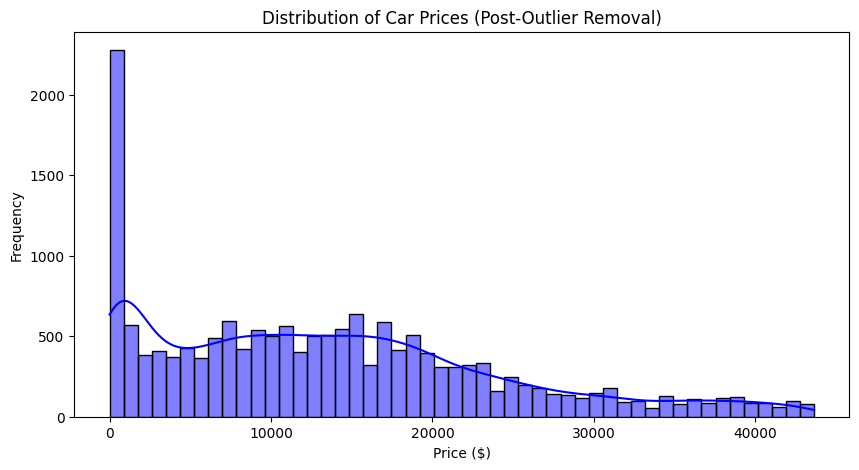

In [ ]:
# 2.5 Outlier Removal via Interquartile Range (IQR)
# Models like Linear Regression are highly sensitive to extreme outliers.
def remove_outliers_iqr(dataframe, column):
    """Filters out data points outside 1.5 * IQR bounds."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

print(f"--- Rows before Outlier Removal: {len(df)} ---")
# Apply IQR filtering to the most volatile continuous features
df = remove_outliers_iqr(df, 'Price')
df = remove_outliers_iqr(df, 'Mileage')
print(f"--- Rows after Outlier Removal: {len(df)} ---")

# Visualize the cleaned Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Car Prices (Post-Outlier Removal)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

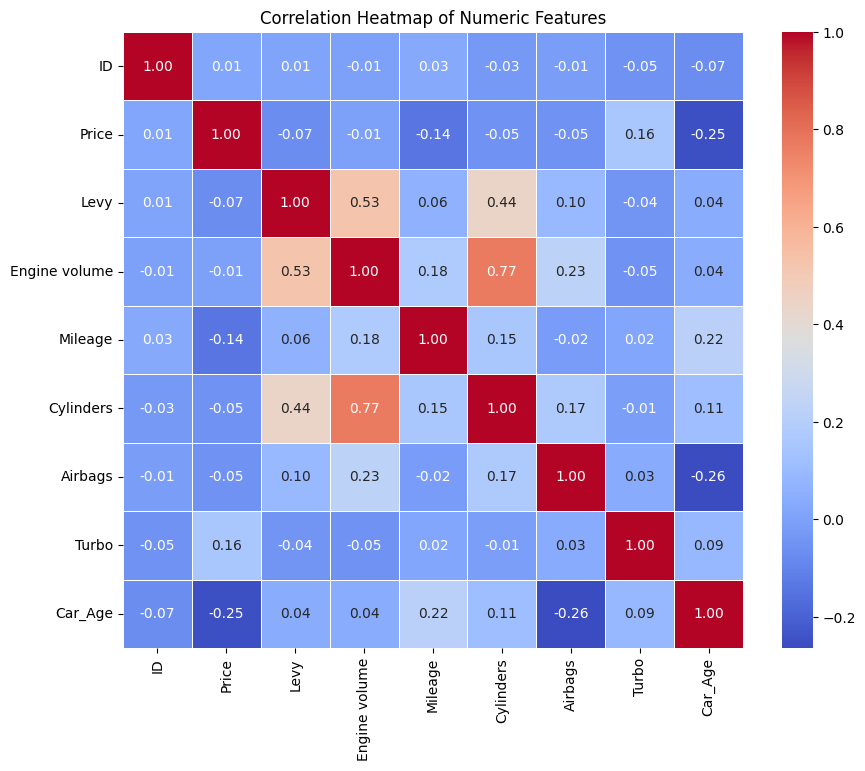

In [ ]:
# ==============================================================================
# Phase 2.75: Deep Exploratory Data Analysis (EDA)
# ==============================================================================

# 1. Correlation Heatmap (Crucial for Regression)
# This shows how strongly each numeric feature is related to Price.
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**Insight: Correlation Heatmap**
* **Engine Volume & Cylinders (0.77):** There is a strong positive correlation between engine volume and the number of cylinders, which is mechanically expected.
* **Price Drivers:** Notably, no single continuous feature shows a massive linear correlation with `Price`. The strongest relationship is a slight negative correlation with `Car_Age` (-0.25). This suggests that predicting used car prices relies heavily on categorical features (like Brand or Model) and non-linear relationships, validating our plan to test advanced algorithms like Random Forest against standard Linear Regression.

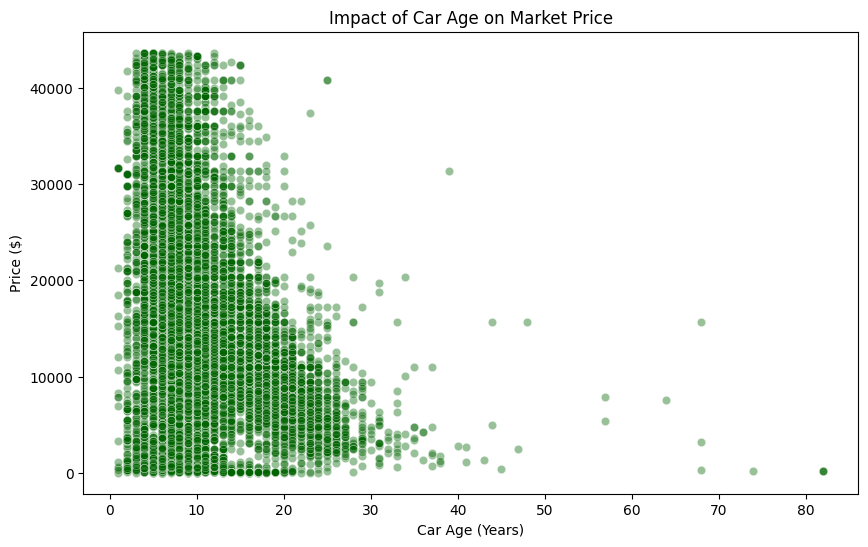

In [ ]:
# 2. Scatter Plot: The Depreciation Curve
# Visualizing how Age affects Price. (You should see a downward trend)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Car_Age', y='Price', data=df, alpha=0.4, color='darkgreen')
plt.title('Impact of Car Age on Market Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Price ($)')
plt.show()

**Insight: Impact of Car Age on Market Price**
* **The Depreciation Curve:** The scatter plot clearly visualizes the depreciation curve of vehicles. The highest density of expensive cars is concentrated between 0 and 15 years of age.
* **The Vintage Effect:** Beyond 30 years, we observe a flattening of the price drop, and even a few slight increases in price for much older models (60+ years). This likely represents the "classic" or "vintage" car market, where age begins to increase value rather than decrease it. Simple linear models will struggle to capture this "U-shape" dynamic.

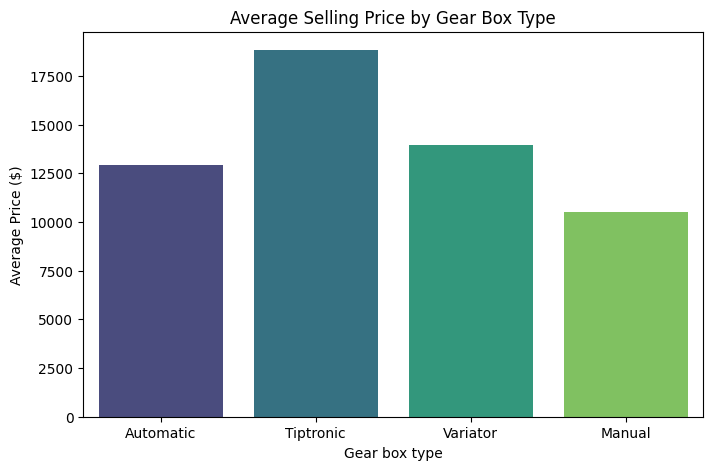

In [ ]:
# 3. Bar Chart: Categorical Impact
# Seeing which Gear Box type commands the highest market value.
plt.figure(figsize=(8, 5))
sns.barplot(x='Gear box type', y='Price', data=df, palette='viridis', errorbar=None)
plt.title('Average Selling Price by Gear Box Type')
plt.ylabel('Average Price ($)')
plt.show()

**Insight: Average Selling Price by Gear Box Type**
* **Tiptronic Dominance:** Interestingly, cars equipped with 'Tiptronic' gearboxes command the highest average selling price (approaching \$19,000), outperforming standard Automatics.
* **Manual Depreciation:** As expected in the modern used car market, 'Manual' transmissions have the lowest average selling price, hovering just above \$10,000. This confirms that `Gear box type` will be a significant predictive feature for our models.

## Phase 3: Final Preprocessing for Machine Learning

In [ ]:
# 3.1 Drop non-predictive columns
# The 'ID' column is an arbitrary database identifier and has no bearing on Price.
# The 'Model' column has 1590 unique values; One-Hot Encoding it would create
# 1590 new columns, leading to extreme dimensionality (the Curse of Dimensionality).
# We drop both to streamline the model.
df_model = df.drop(['ID', 'Model'], axis=1)

print("First 5 records:", df.head())

First 5 records:          ID  Price    Levy Manufacturer    Model   Category Leather interior  \
0  45654403  13328  1399.0        LEXUS   RX 450       Jeep              Yes   
1  44731507  16621  1018.0    CHEVROLET  Equinox       Jeep               No   
2  45774419   8467   781.0        HONDA      FIT  Hatchback               No   
3  45769185   3607   862.0         FORD   Escape       Jeep              Yes   
4  45809263  11726   446.0        HONDA      FIT  Hatchback              Yes   

  Fuel type  Engine volume  Mileage  Cylinders Gear box type Drive wheels  \
0    Hybrid            3.5   186005        6.0     Automatic          4x4   
1    Petrol            3.0   192000        6.0     Tiptronic          4x4   
2    Petrol            1.3   200000        4.0      Variator        Front   
3    Hybrid            2.5   168966        4.0     Automatic          4x4   
4    Petrol            1.3    91901        4.0     Automatic        Front   

  Doors             Wheel   Color  Airb

In [ ]:
# 3.2 Categorical Encoding (One-Hot Encoding)
# We convert all remaining text categories into binary columns (0 or 1).
# drop_first=True prevents the "dummy variable trap" (perfect multicollinearity).
categorical_cols = df_model.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

In [ ]:
# 3.3 Define Features (X) and Target (y)
X = df_encoded.drop('Price', axis=1) # Everything EXCEPT Price
y = df_encoded['Price']              # ONLY Price

In [ ]:
# 3.4 Train/Test Split
# We split the data: 80% for the models to learn from, 20% to test their accuracy.
# random_state=42 ensures we get the exact same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3.5 Feature Scaling
# We scale the data so large numbers (Mileage) don't overpower small ones (Cylinders).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Only transform the test set to prevent data leakage

In [ ]:
print(f"--- Phase 3 Complete ---")
print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")

--- Phase 3 Complete ---
Training Data Shape: (13449, 106)
Testing Data Shape: (3363, 106)
